In [1]:
import matplotlib.pyplot as plt
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Paramètres — Paris
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": 48.85,
    "longitude": 2.35,
    "hourly": ["pm2_5", "nitrogen_dioxide", "ozone", "dust", "european_aqi"],
    "past_days": 90
}

responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

Coordinates: 48.80000305175781°N 2.3999996185302734°E
Elevation: 46.0 m asl
Timezone difference to GMT+0: 0s


In [2]:
hourly = response.Hourly()
hourly_pm2_5 = hourly.Variables(0).ValuesAsNumpy()
hourly_no2 = hourly.Variables(1).ValuesAsNumpy()
hourly_o3 = hourly.Variables(2).ValuesAsNumpy()
hourly_dust = hourly.Variables(3).ValuesAsNumpy()
hourly_aqi = hourly.Variables(4).ValuesAsNumpy()

df = pd.DataFrame({
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "pm2_5": hourly_pm2_5,
    "no2": hourly_no2,
    "o3": hourly_o3,
    "dust": hourly_dust,
    "european_aqi": hourly_aqi,
})         # index 2 = ozone

print(df.shape)
print(df.describe())

(2280, 6)
             pm2_5          no2           o3         dust  european_aqi
count  2269.000000  2269.000000  2269.000000  2269.000000   2270.000000
mean     11.814643    26.425398    51.834290     1.345086     30.972130
std       8.397671    18.905851    27.492178     3.769880     12.142203
min       2.100000     2.300000     0.000000     0.000000     11.200000
25%       6.000000    12.000000    31.000000     0.000000     22.885418
50%       9.100000    20.799999    54.000000     0.000000     28.000000
75%      15.000000    36.599998    71.000000     1.000000     34.799999
max      50.700001   101.800003   118.000000    30.000000     72.513336


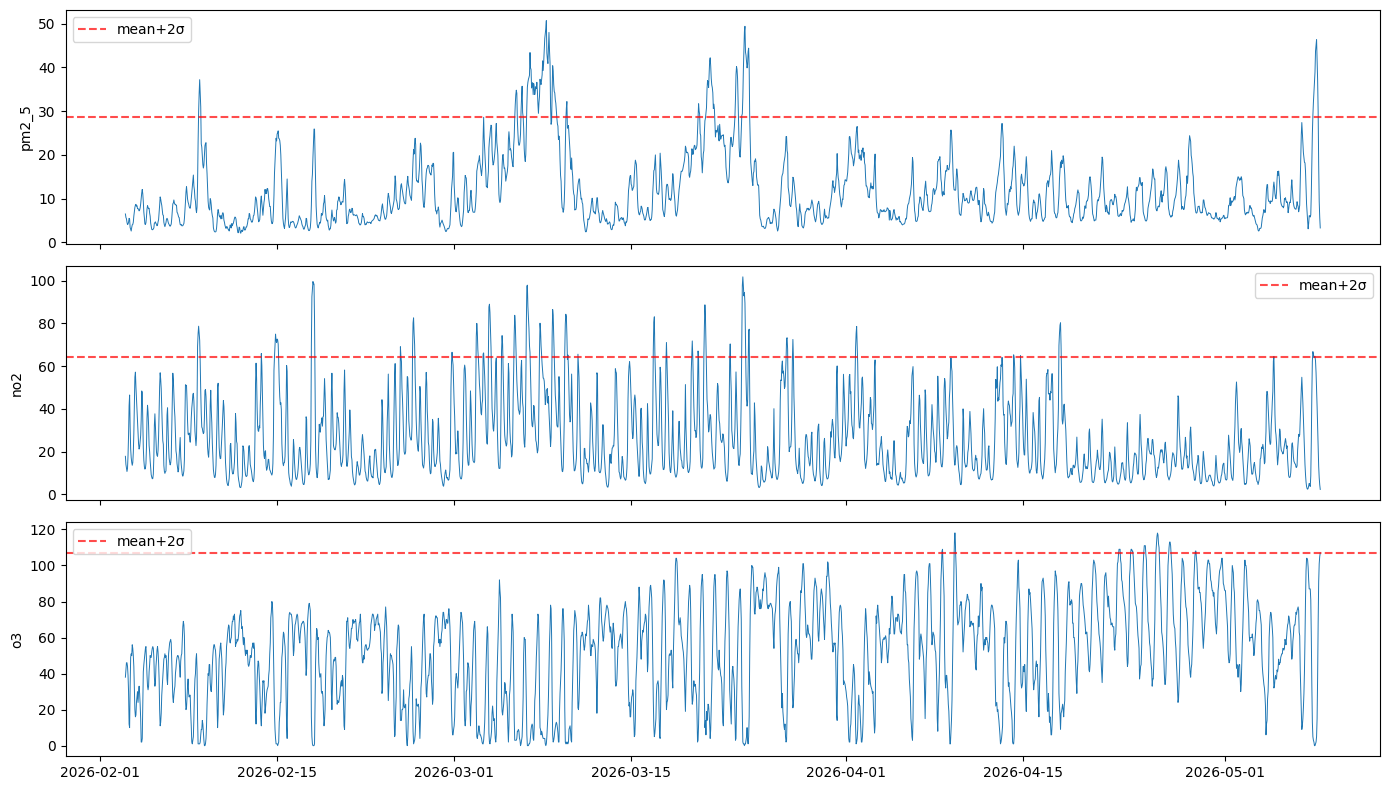

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, col in zip(axes, ["pm2_5", "no2", "o3"]):
    ax.plot(df["date"], df[col], linewidth=0.7)
    mean, std = df[col].mean(), df[col].std()
    ax.axhline(mean + 2*std, color="red", linestyle="--", alpha=0.7, label="mean+2σ")
    ax.set_ylabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

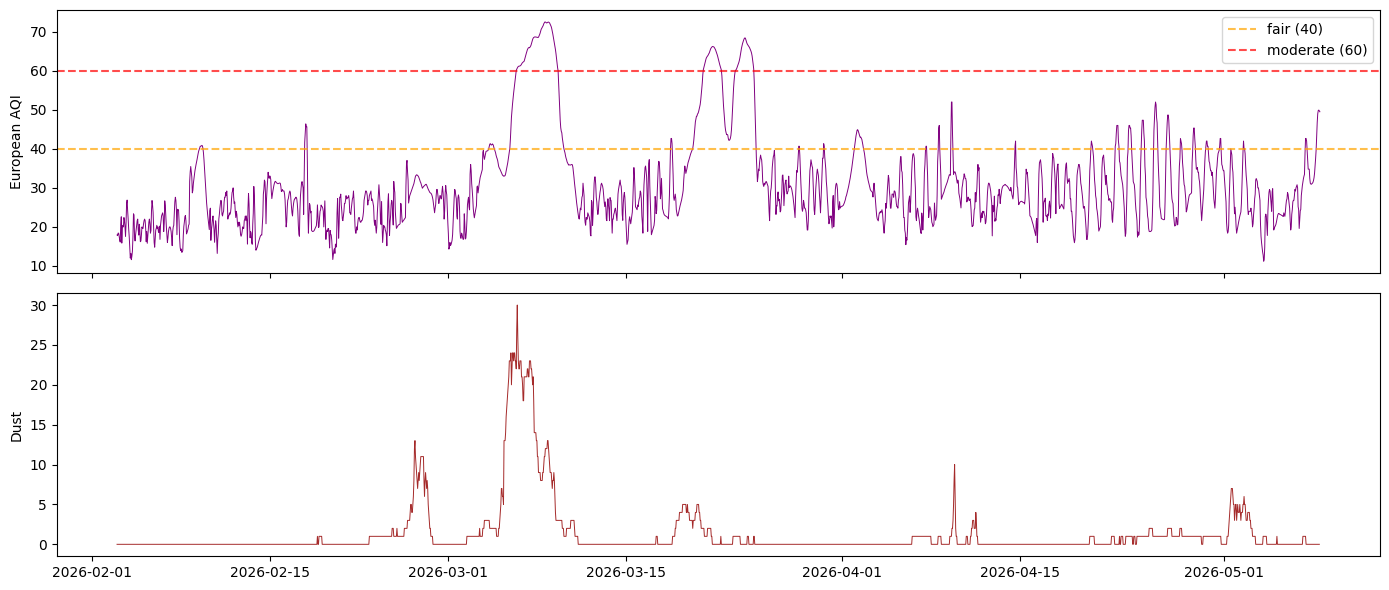

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df["date"], df["european_aqi"], linewidth=0.7, color="purple")
axes[0].axhline(40, color="orange", linestyle="--", alpha=0.7, label="fair (40)")
axes[0].axhline(60, color="red", linestyle="--", alpha=0.7, label="moderate (60)")
axes[0].set_ylabel("European AQI")
axes[0].legend()

axes[1].plot(df["date"], df["dust"], linewidth=0.7, color="brown")
axes[1].set_ylabel("Dust")

plt.tight_layout()
plt.show()

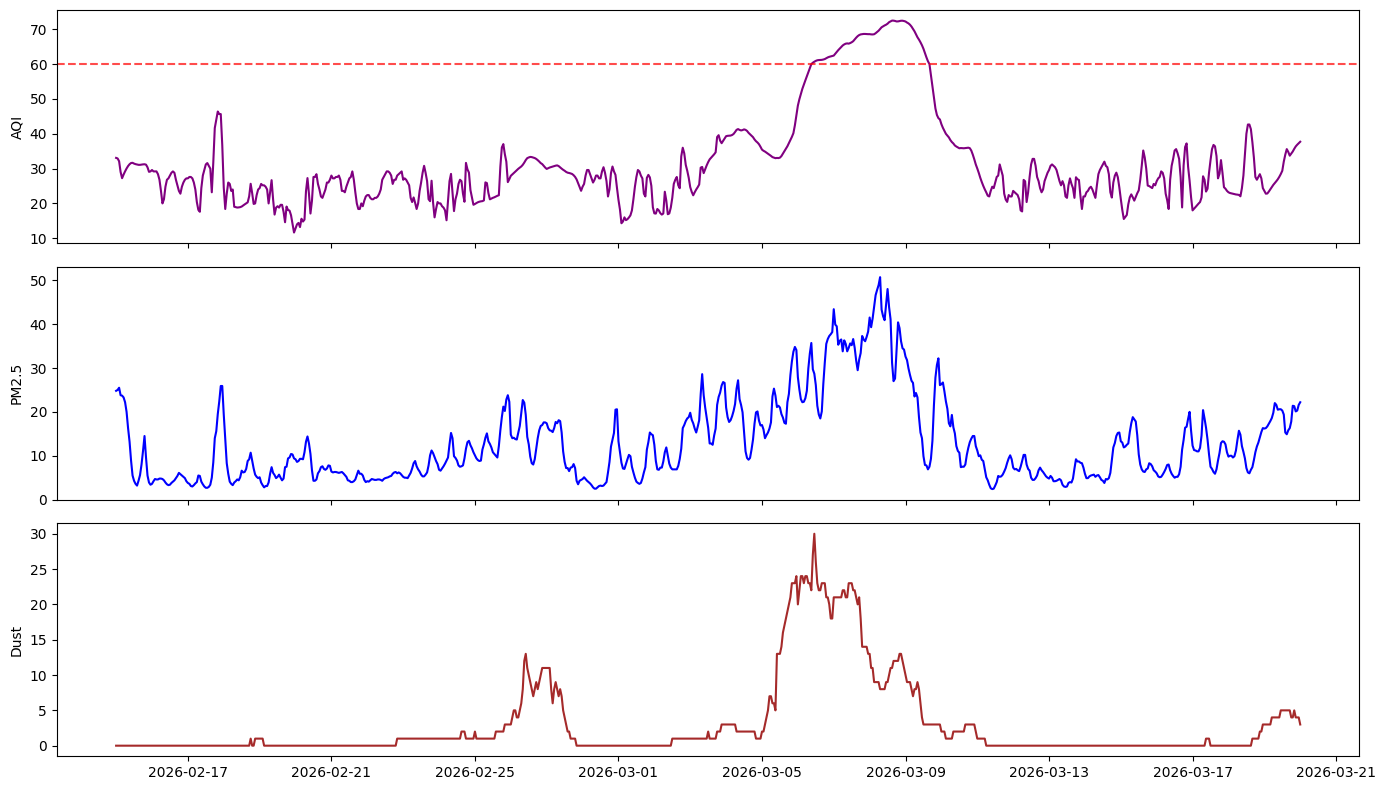

In [5]:
# Zoom sur février-mars pour voir la corrélation
mask = (df["date"] >= "2026-02-15") & (df["date"] <= "2026-03-20")
df_zoom = df[mask]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_zoom["date"], df_zoom["european_aqi"], color="purple")
axes[0].axhline(60, color="red", linestyle="--", alpha=0.7)
axes[0].set_ylabel("AQI")

axes[1].plot(df_zoom["date"], df_zoom["pm2_5"], color="blue")
axes[1].set_ylabel("PM2.5")

axes[2].plot(df_zoom["date"], df_zoom["dust"], color="brown")
axes[2].set_ylabel("Dust")

plt.tight_layout()
plt.show()

In [14]:
weather_params = {
    "latitude": 48.85,
    "longitude": 2.35,
    "hourly": [
        "temperature_2m",
        "wind_speed_10m", 
        "wind_direction_10m",
        "precipitation",
        "relative_humidity_2m"
    ],
    "start_date": "2026-02-01",
    "end_date": "2026-05-04"
}

weather_responses = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive",  # <- URL différente
    params=weather_params
)

In [22]:
weather_response = weather_responses[0]

hourly_w = weather_response.Hourly()
df_weather = pd.DataFrame({
    "date": pd.date_range(
        start=pd.to_datetime(hourly_w.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly_w.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly_w.Interval()),
        inclusive="left"
    ),
    "temperature": hourly_w.Variables(0).ValuesAsNumpy(),
    "wind_speed": hourly_w.Variables(1).ValuesAsNumpy(),
    "wind_direction": hourly_w.Variables(2).ValuesAsNumpy(),
    "precipitation": hourly_w.Variables(3).ValuesAsNumpy(),
    "humidity": hourly_w.Variables(4).ValuesAsNumpy(),
})

# Merger avec df qualité de l'air
df_full = pd.merge(df, df_weather, on="date", how="inner")
print(df_full.shape)
print(df_full.describe())

(2184, 12)
             pm2_5          no2           o3         dust  european_aqi  \
count  2184.000000  2184.000000  2184.000000  2184.000000   2184.000000   
mean     11.701327    26.509892    51.728024     1.394231     31.020100   
std       8.289199    18.961603    27.459366     3.833787     12.277077   
min       2.100000     3.200000     0.000000     0.000000     11.200000   
25%       5.900000    11.900000    31.000000     0.000000     22.799999   
50%       9.000000    20.799999    54.000000     0.000000     28.000000   
75%      14.900000    37.025000    71.000000     1.000000     34.914580   
max      50.700001   101.800003   118.000000    30.000000     72.513336   

       temperature   wind_speed  wind_direction  precipitation     humidity  
count  2184.000000  2184.000000     2184.000000    2184.000000  2184.000000  
mean     10.946886    10.605425      180.402298       0.096566    72.068939  
std       4.690157     5.335882       95.792519       0.378635    19.609955  
m

In [23]:
df.date.max()

Timestamp('2026-05-08 23:00:00+0000', tz='UTC')

In [24]:
df.dropna().date.max()

Timestamp('2026-05-08 12:00:00+0000', tz='UTC')

In [25]:
df_weather.date.max()

Timestamp('2026-05-04 23:00:00+0000', tz='UTC')

In [26]:
df_weather

,date,temperature,wind_speed,wind_direction,precipitation,humidity
0,2026-02-01 00:00:00+00:00,5.80,8.936777,198.799988,0.0,95.924667
1,2026-02-01 01:00:00+00:00,6.50,8.936777,198.799988,0.0,96.279175
2,2026-02-01 02:00:00+00:00,5.70,8.209263,195.255173,0.0,97.264320
3,2026-02-01 03:00:00+00:00,5.05,9.215226,192.407410,0.0,97.931282
4,2026-02-01 04:00:00+00:00,5.05,10.362123,197.175995,0.0,97.931282
...,...,...,...,...,...,...
2227,2026-05-04 19:00:00+00:00,14.25,4.873315,355.763672,0.4,94.016411
2228,2026-05-04 20:00:00+00:00,14.00,5.582902,358.152435,0.3,95.551186
2229,2026-05-04 21:00:00+00:00,13.80,5.068846,16.504446,0.0,95.856766
2230,2026-05-04 22:00:00+00:00,13.55,4.553679,18.435053,0.0,96.793106


In [20]:
df["day"] = df["date"].dt.date
daily_max = df.groupby("day")["european_aqi"].max()
aqi_threshold = daily_max.mean() + 2 * daily_max.std()

print("Seuil anomalie:", round(aqi_threshold, 1))
print("\nJours anomaux:")
print(daily_max[daily_max > aqi_threshold].sort_values(ascending=False))
print("\nJours normaux (AQI < 30):")
print(daily_max[daily_max < 30].sample(5, random_state=42))

Seuil anomalie: 61.7

Jours anomaux:
day
2026-03-08    72.513336
2026-03-09    72.249992
2026-03-07    68.679993
2026-03-24    68.416664
2026-03-21    66.220001
2026-03-22    65.646667
2026-03-23    63.353340
2026-03-06    62.326664
Name: european_aqi, dtype: float32

Jours normaux (AQI < 30):
day
2026-02-03    26.879999
2026-02-04    23.360001
2026-02-10    27.691668
2026-05-04    29.799999
2026-03-01    29.600000
Name: european_aqi, dtype: float32


In [27]:
df = df_full.copy()
mask = (df["date"].dt.date >= pd.to_datetime("2026-04-07").date()) & \
       (df["date"].dt.date <= pd.to_datetime("2026-04-09").date())
df[mask].groupby("day")[["o3", "european_aqi", "temperature", "dust"]].max()

,o3,european_aqi,temperature,dust
day,,,,
2026-04-07,101.0,40.666664,23.100000,1.0
2026-04-08,109.0,46.000000,24.049999,1.0
2026-04-09,118.0,52.000000,25.799999,10.0


In [31]:
df_full.to_csv("data/air_quality_snapshot.csv", index=False)
print(f"Saved {len(df_full)} rows")

Saved 2184 rows


In [ ]:
from src.agent import app

png = app.get_graph().draw_mermaid_png()

with open("graph.png", "wb") as f:
    f.write(png)